# Lecture 18: Decisions — Hypothesis Testing
v.ekc

Everything we've been doing informally gets its official name today: the **hypothesis test**. Null, alternative, test statistic, p-value, the vocabulary of statistical decisions.

**Today's sections:**
1. Alameda County, concluded
2. Is the difference significant??
3. Making the decision

### 📋 Reference Table — the hypothesis test

| Step | Meaning |
|---|---|
| **Null hypothesis** | "nothing special — it's chance"; precise enough to simulate |
| **Alternative** | "something other than chance is going on" |
| **Test statistic** | one number; choose so *big* (or *small*) favors the alternative |
| **Prediction under the null** | simulate the statistic assuming the null |
| **Conclusion** | observed value consistent with simulation → null stands; way out in the tail → reject null hypothesis|

In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

---
## 1. Alameda County, Concluded

The TVD test from last time, start to finish, this *is* a hypothesis test; we just hadn't named the parts yet.

In [2]:
jury = Table().with_columns(
    'Ethnicity', make_array('Asian', 'Black', 'Latino', 'White', 'Other'),
    'Eligible', make_array(0.15, 0.18, 0.12, 0.54, 0.01),
    'Panels', make_array(0.26, 0.08, 0.08, 0.54, 0.04)
)

jury

Ethnicity,Eligible,Panels
Asian,0.15,0.26
Black,0.18,0.08
Latino,0.12,0.08
White,0.54,0.54
Other,0.01,0.04


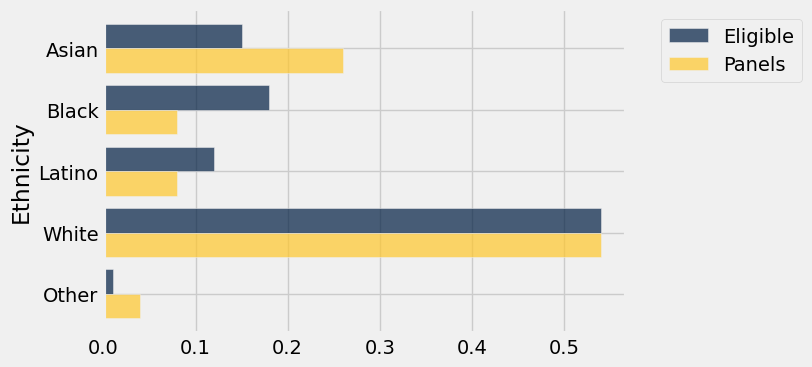

In [3]:
jury.barh('Ethnicity')

The model, straight which we just grab as an array from our 'Eligible' column in the table :)

In [4]:
# Under the model, this is the true distribution of people
# from which the jurors are randomly sampled
model = jury.column('Eligible')
model

array([ 0.15,  0.18,  0.12,  0.54,  0.01])

In [5]:
# Let's simulate a random draw of 1423 jurors from this distribution
simulated = sample_proportions(1423, model)
simulated

array([ 0.15038651,  0.18552354,  0.11946592,  0.53408292,  0.01054111])

Attach the simulated draw and compare, in table form and in bars:

In [6]:
# The actual observed distribution (Panels) looks quite different
#    from the simulation........try running this several times to confirm!
jury_with_simulated = jury.with_column('Simulated', simulated)
jury_with_simulated

Ethnicity,Eligible,Panels,Simulated
Asian,0.15,0.26,0.150387
Black,0.18,0.08,0.185524
Latino,0.12,0.08,0.119466
White,0.54,0.54,0.534083
Other,0.01,0.04,0.0105411


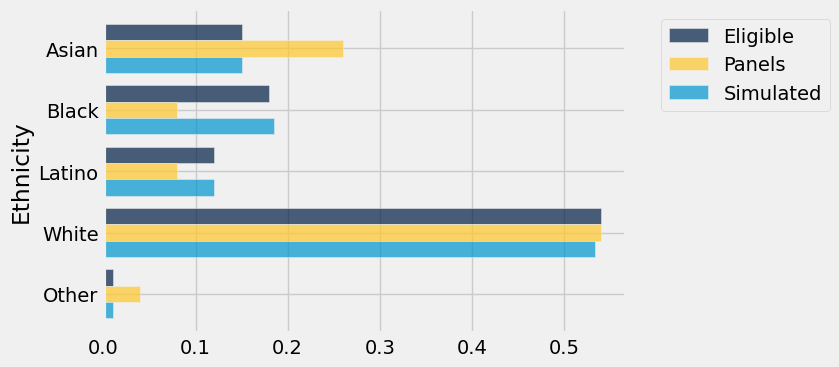

In [7]:
jury_with_simulated.barh('Ethnicity')

### Distance Between Distributions

In [8]:
#  In the Mendel model from before, the difference between observed white/purple
# and their expected values (25%/75%) was our statistic.
#
# In this case, we need to understand how each of the 5 categories
# differ from their expected values according to the model.

diffs = jury.column('Panels') - jury.column('Eligible')
jury_with_difference = jury.with_column('Difference', diffs)
jury_with_difference

Ethnicity,Eligible,Panels,Difference
Asian,0.15,0.26,0.11
Black,0.18,0.08,-0.1
Latino,0.12,0.08,-0.04
White,0.54,0.54,0
Other,0.01,0.04,0.03


### Total Variation Distance

In [9]:
def tvd(dist1, dist2):
    return sum(abs(dist1 - dist2))/2

In [10]:
# The TVD of our observed data (Panels) from their expected values
# assuming the model is true (Eligible)
obsvd_tvd = tvd(jury.column('Panels'), jury.column('Eligible'))
obsvd_tvd

0.14000000000000001

#### TVD statistic
Here, we create one simulated TVD statistic, just to get an idea of what to expect.

Since we are going off the model for the distribution, the TVD should be close to zero!

In [11]:
# The TVD of a model simulation from its expected values
tvd(sample_proportions(1423, model), model)

0.017498243148278241

#### TVD statistic x 10,000 -> empirical distribution of the TVD statistic
Now, let's create an empirical distribution for the TVD statistic....we simulate a 1423-person jury, calculate the TVD, then 10,000 times!!!!!!!

Here is the result

In [12]:
def simulated_tvd():
    return tvd(sample_proportions(1423, model), model)

tvds = make_array()

num_simulations = 10000
for i in np.arange(num_simulations):
    new_tvd = simulated_tvd()
    tvds = np.append(tvds, new_tvd)

Observed TVD: 0.14


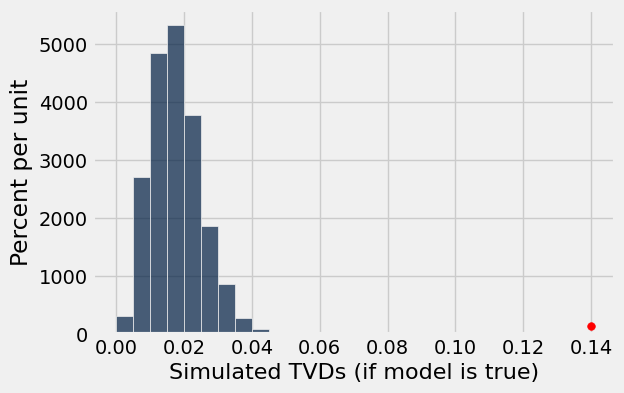

In [14]:
title = 'Simulated TVDs (if model is true)'
bins = np.arange(0, .05, .005)

Table().with_column(title, tvds).hist(bins = bins)
print('Observed TVD: ' + str(obsvd_tvd))
plots.scatter(0.14,1.3,color='r',s=30);

### Try It 1: How rare is 0.14? 😊

1. Out of the 10,000 simulated TVDs, how many are at least as large as the observed TVD? (`tvds` and `obsvd_tvd` are in memory.)

2. In hypothesis-test language: what does that count say about the null?

In [ ]:
# 1. simulated TVDs at or beyond observed


*2. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Count the simulations at or beyond the data.*

```python
# 1.
np.count_nonzero(tvds >= obsvd_tvd)
```

*2. Zero out of 10,000. Chance alone essentially never produces panels this far from the eligible distribution, so we reject the null that panels are random draws from it.*

</details>

---
## 2. The TA's Defense 🎓

A class of 359 students in 12 sections. Section 3's average midterm score (13.67) is noticeably below the class average (15.49). The TA says: *"it's just chance; my section is like a random sample of the class."* That's a **null hypothesis**, and it's simulatable.

> **Null:** Section 3's average is like the average of 27 students drawn at random from the class.
> **Alternative:** No, it's systematically lower.
> **Test statistic:** the sample average (small values favor the alternative).

In [15]:
scores = Table.read_table('scores_by_section.csv')
scores

Section,Midterm
1,22
2,12
2,23
2,14
1,20
3,25
4,19
1,24
5,8
6,14


In [16]:
scores.group('Section')

Section,count
1,32
2,32
3,27
4,30
5,33
6,32
7,24
8,29
9,30
10,34


Averages next. Keep an eye on Section 3:

In [17]:
scores.group('Section', np.average).show()

Section,Midterm average
1,15.5938
2,15.125
3,13.6667
4,14.7667
5,17.4545
6,15.0312
7,16.625
8,16.3103
9,14.5667
10,15.2353


In [18]:
observed_average = 13.6667 

The null in action: draw 27 students at random and average them:

In [19]:
random_sample = scores.sample(27, with_replacement=False)
random_sample

Section,Midterm
10,12
1,13
8,25
8,21
10,23
1,22
6,12
10,0
2,11
10,20


In [20]:
np.average(random_sample.column('Midterm'))

16.0

Package the draw into a function, then repeat it 50,000 times:

In [21]:
# Simulate one value of the test statistic 
# under the hypothesis that the section is like a random sample from the class
def random_sample_midterm_avg():
    random_sample = scores.sample(27, with_replacement = False)
    return np.average(random_sample.column('Midterm'))

In [22]:
# Simulate 50,000 copies of the test statistic

sample_averages = make_array()

for i in np.arange(50000):
    sample_averages = np.append(sample_averages, random_sample_midterm_avg())    

---
## 3. Making the Decision

Where does 13.67 fall among 50,000 simulated section averages? Two equivalent ways to decide:

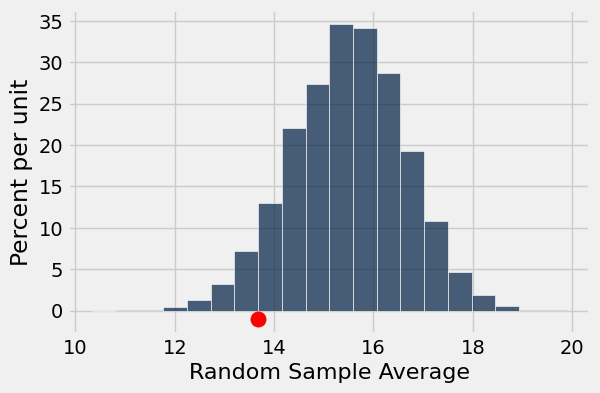

In [23]:
# Compare the simulated distribution of the statistic
# and the actual observed statistic
averages_tbl = Table().with_column('Random Sample Average', sample_averages)
averages_tbl.hist(bins = 20)
plots.scatter(observed_average, -0.01, color='red', s=120);

### Approach 1 — the p-value

What fraction of simulations were *as extreme or more* than the observed value?

In [24]:
# (1) Calculate the p-value: simulation area beyond observed value
np.count_nonzero(sample_averages <= observed_average) / 50000
# (2) See if this is less than 5%

0.05866

### Approach 2 — the 5% cutoff

Find the value that cuts off the bottom 5% of simulations; is the observation below it?

In [25]:
# (1) Find simulated value corresponding to 5% of 50,000 = 2500
five_percent_point = averages_tbl.sort(0).column(0).item(2500)
five_percent_point

13.592592592592593

In [26]:
# (2) See if this value is greater than observed value
observed_average

13.6667

### Visual Representation

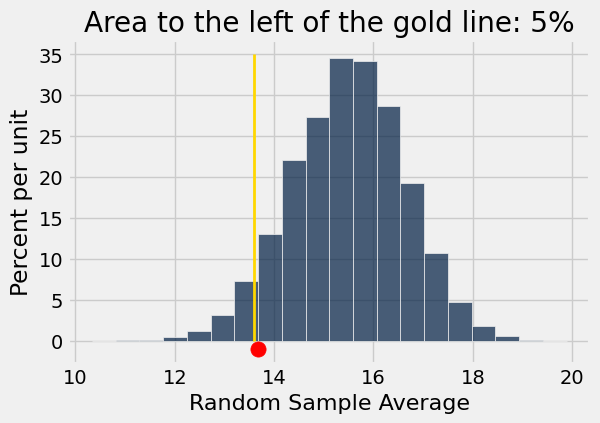

In [27]:
averages_tbl.hist(bins = 20)
plots.plot([five_percent_point, five_percent_point], [0, 0.35], color='gold', lw=2)
plots.title('Area to the left of the gold line: 5%');
plots.scatter(observed_average, -0.01, color='red', s=120);

### Try It 2: Section 5's turn 😊

Section 5 (33 students) averaged **17.45**, well *above* the class average. Is that chance?

1. Simulate 10,000 averages of 33 randomly sampled students. (Careful: the sample size changed!)

2. Compute the p-value for Section 5. Which tail counts this time?

3. Using the 5% convention, what do you conclude about Section 5?

In [ ]:
# 1. 10,000 averages of 33 random students


In [ ]:
# 2. p-value, upper tail


*3. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*High values favor this alternative, so the p-value counts the upper tail.*

```python
# 1.
def random_33_avg():
    return np.average(scores.sample(33, with_replacement=False).column('Midterm'))

averages_33 = make_array()
for i in np.arange(10000):
    averages_33 = np.append(averages_33, random_33_avg())

# 2.
observed_sec5 = 17.4545
np.count_nonzero(averages_33 >= observed_sec5) / 10000
```

*3. The p-value comes out around 0.02, below the 5% cutoff, so under the convention Section 5's high average is statistically significant too. Note the flipped direction: this time large values of the statistic favor the alternative.*

</details>

> **Conventions**: $p < 0.05$ → "statistically significant"; $p < 0.01$ → "highly significant." These cutoffs are customs, not laws of nature, the p-value itself is the honest summary. Here $p \approx 0.05–0.06$: right on the boundary, so reasonable people can disagree, and that's a legitimate outcome of a test.

### Try It 3: Name the parts 🏷️

1. For the *Swain v. Alabama* analysis, state the null hypothesis, the alternative, and the test statistic. (No code, just write it in the cell below.)

*1. Your answer: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Null: panels are drawn at random from the eligible population (26% Black men). Alternative: the process under-selects Black men. Test statistic: number of Black men on a panel of 100; small values favor the alternative.*

</details>

---
> **Today's takeaway:** null + alternative + test statistic + simulation + comparison = hypothesis test. You've been doing it for a week; now you can name every part. Homework 6 asks you to run this recipe solo.

## Appendix — Quick Reference

Full `datascience` docs: [data8.org/datascience](https://data8.org/datascience/)

### Minimal template — p-value
```python
p_value = np.count_nonzero(simulated_stats <= observed_stat) / len(simulated_stats)
```